In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("C:/Users/NETI GEETHIKA/Documents/E_commerce_intern/Online Retail.xlsx")

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.drop_duplicates(inplace=True)

In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Country'] = encoder.fit_transform(df['Country'])

In [20]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [21]:
customer_data = df.groupby('CustomerID').agg({
    'TotalPrice':'sum',
    'InvoiceNo':'count'
})

In [22]:
customer_data.columns = ['TotalSpending', 'PurchaseFrequency']

In [23]:
customer_data.head()

,TotalSpending,PurchaseFrequency
CustomerID,,
12346.0,0.00,2
12347.0,4310.00,182
12348.0,1797.24,31
12349.0,1757.55,73
12350.0,334.40,17


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(customer_data)

In [25]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

customer_data['Cluster'] = kmeans.fit_predict(scaled_data)

In [26]:
customer_data.head()

,TotalSpending,PurchaseFrequency,Cluster
CustomerID,,,
12346.0,0.00,2,0
12347.0,4310.00,182,0
12348.0,1797.24,31,0
12349.0,1757.55,73,0
12350.0,334.40,17,0


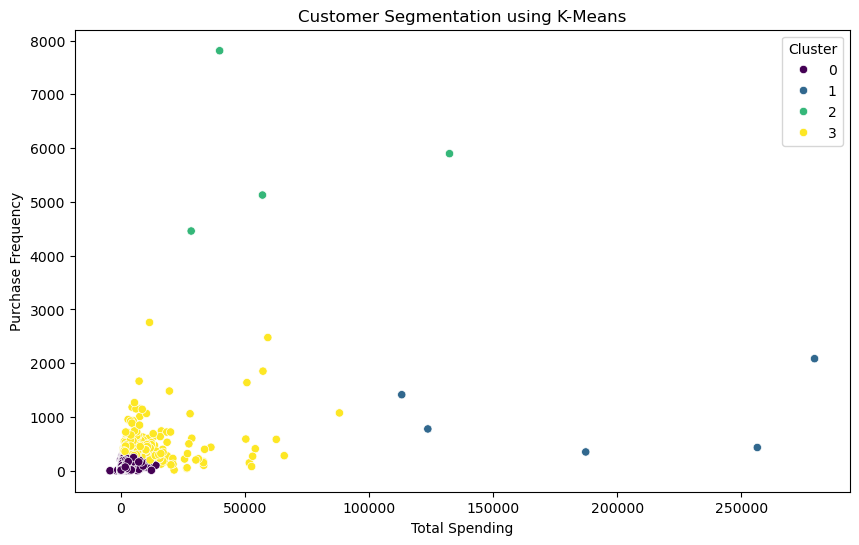

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=customer_data['TotalSpending'],
    y=customer_data['PurchaseFrequency'],
    hue=customer_data['Cluster'],
    palette='viridis'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Total Spending")
plt.ylabel("Purchase Frequency")

plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Country'] = encoder.fit_transform(df['Country'])
